
# Tarefa de Machine Learning: Regressão e Classificação
**Autor:** Pedro Tonelli  
**Objetivo:** Desenvolver pipelines de ML para predição de notas de alunos (Regressão) e diagnóstico de tumores de mama (Classificação), gerando predições para a competição do Kaggle.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Modelos de Regressao
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Modelos de Classificacao
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [3]:
# Configuracao de plots
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

---
## Parte 1: Regressão — Student Performance
**Objetivo:** Prever a nota média `score = mean(G1, G2, G3)` dos alunos com base em variáveis demográficas, socioeconômicas e comportamentais.



In [4]:
train_reg = pd.read_csv('regressao/train.csv')
test_reg = pd.read_csv('regressao/test.csv')

print(f"Treino Regressão Shape: {train_reg.shape}")
print(f"Teste Regressão Shape: {test_reg.shape}")
train_reg.head()

Treino Regressão Shape: (395, 31)
Teste Regressão Shape: (40, 30)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,score
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,6,5.67
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,4,5.33
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,10,8.33
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,2,14.67
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,4,8.67


--- Informações do Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   school      395 non-null    object 
 1   sex         395 non-null    object 
 2   age         395 non-null    int64  
 3   address     395 non-null    object 
 4   famsize     395 non-null    object 
 5   Pstatus     395 non-null    object 
 6   Medu        395 non-null    int64  
 7   Fedu        395 non-null    int64  
 8   Mjob        395 non-null    object 
 9   Fjob        395 non-null    object 
 10  reason      395 non-null    object 
 11  guardian    395 non-null    object 
 12  traveltime  395 non-null    int64  
 13  studytime   395 non-null    int64  
 14  failures    395 non-null    int64  
 15  schoolsup   395 non-null    object 
 16  famsup      395 non-null    object 
 17  paid        395 non-null    object 
 18  activities  395 non-null    object 
 19

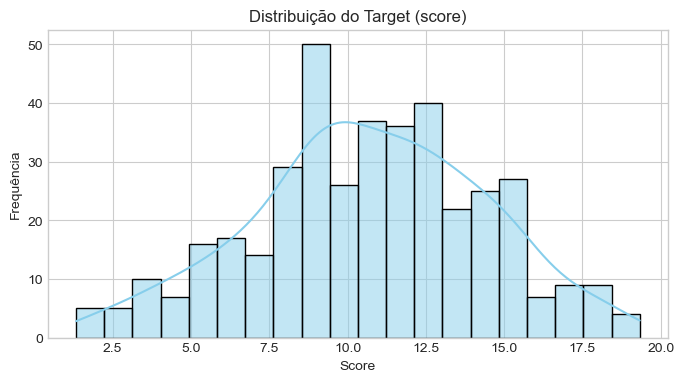

In [5]:
# Analise Exploratoria (EDA)
print("--- Informações do Dataset ---")
train_reg.info()
print("\n--- Estatísticas da Variável Alvo (score) ---")
print(train_reg['score'].describe())

plt.figure(figsize=(8, 4))
sns.histplot(train_reg['score'], kde=True, bins=20, color='skyblue')
plt.title("Distribuição do Target (score)")
plt.xlabel("Score")
plt.ylabel("Frequência")
plt.show()

In [6]:
# 1.2 Limpeza e Pre-processamento (Pipeline)
X_reg = train_reg.drop(columns=['score'])
y_reg = train_reg['score']

# Separacao de colunas numericas e categoricas
num_cols_reg = X_reg.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols_reg = X_reg.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_reg),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols_reg)
    ]
)

# Split de validacao interna
X_train_r, X_val_r, y_train_r, y_val_r = train_test_split(X_reg, y_reg, random_state=42, test_size=0.2)



In [7]:
# 1.3 Modelagem e Comparacao (RMSE Cross-Validation)
models_reg = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "KNN Regressor": KNeighborsRegressor(),
    "SVR": SVR(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results_reg = []

for name, model in models_reg.items():
    pipe = Pipeline(steps=[('prep', preprocessor_reg), ('algo', model)])
    scores = cross_val_score(pipe, X_reg, y_reg, cv=5, scoring='neg_root_mean_squared_error')
    rmse_mean = -scores.mean()
    rmse_std = scores.std()
    results_reg.append({"Modelo": name, "RMSE_CV": rmse_mean, "STD": rmse_std})

df_res_reg = pd.DataFrame(results_reg).sort_values(by="RMSE_CV")
print("--- Validação Cruzada (Regressão - RMSE) ---")
print(df_res_reg.to_string(index=False))

c:\Users\user\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unk

--- Validação Cruzada (Regressão - RMSE) ---
           Modelo  RMSE_CV      STD
    Random Forest 3.435877 0.323045
              SVR 3.441950 0.376442
       ElasticNet 3.526685 0.330014
            Ridge 3.532119 0.313783
Gradient Boosting 3.539807 0.304271
Linear Regression 3.554706 0.308234
            Lasso 3.587168 0.357970
    KNN Regressor 3.742373 0.399366
    Decision Tree 4.844807 0.475389


c:\Users\user\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [16]:
# Treinamento do Melhor Modelo de Regressao (Random Forest / Ridge / Gradient Boosting)
best_reg_pipe = Pipeline(steps=[('prep', preprocessor_reg), ('algo', GradientBoostingRegressor(random_state=42))])
best_reg_pipe.fit(X_reg, y_reg)

# Predicao no conjunto de teste para submissao
preds_reg = best_reg_pipe.predict(test_reg)

sub_reg = pd.DataFrame({
    'id': range(len(preds_reg)),  # Cria os IDs de 0 a len(preds)-1
    'score': np.round(preds_reg, 2)
})

sub_reg.to_csv('submission_regressao.csv', index=False)
print(f"Submissão gerada com {len(sub_reg)} linhas!")
sub_reg.head()


Submissão gerada com 40 linhas!


,id,score
0,0,13.34
1,1,11.42
2,2,4.77
3,3,11.55
4,4,11.98


 ---
 ## Parte 2: Classificação — Breast Cancer Wisconsin
 **Objetivo:** Classificar o diagnóstico entre `M` (Maligno) e `B` (Benigno).

In [9]:

train_cls = pd.read_csv('classiicacao/train2.csv')
test_cls = pd.read_csv('classiicacao/test2.csv')

print(f"Treino Classificação Shape: {train_cls.shape}")
print(f"Teste Classificação Shape: {test_cls.shape}")

print("\n--- Distribuição das Classes (diagnosis) ---")
print(train_cls['diagnosis'].value_counts(normalize=True))

Treino Classificação Shape: (569, 31)
Teste Classificação Shape: (40, 30)

--- Distribuição das Classes (diagnosis) ---
diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64


In [10]:
# 2.2 Pre-processamento
X_cls = train_cls.drop(columns=['diagnosis'])
y_cls = train_cls['diagnosis']

# Pipeline de normalizacao
scaler_cls = StandardScaler()
X_cls_scaled = scaler_cls.fit_transform(X_cls)
test_cls_scaled = scaler_cls.transform(test_cls)

X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

In [11]:
# 2.3 Modelagem e Avaliacao
models_cls = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Gaussian NB": GaussianNB(),
    "SVC": SVC(probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results_cls = []

for name, model in models_cls.items():
    pipe = Pipeline(steps=[('scaler', StandardScaler()), ('algo', model)])
    scores = cross_val_score(pipe, X_cls, y_cls, cv=5, scoring='accuracy')
    results_cls.append({"Modelo": name, "Acurácia_CV": scores.mean(), "STD": scores.std()})

df_res_cls = pd.DataFrame(results_cls).sort_values(by="Acurácia_CV", ascending=False)
print("--- Validação Cruzada (Classificação - Acurácia) ---")
print(df_res_cls.to_string(index=False))

--- Validação Cruzada (Classificação - Acurácia) ---
             Modelo  Acurácia_CV      STD
Logistic Regression     0.980686 0.006539
                SVC     0.973638 0.014679
                KNN     0.964850 0.009610
  Gradient Boosting     0.961372 0.023899
      Random Forest     0.956094 0.022839
        Gaussian NB     0.927930 0.020359
      Decision Tree     0.917342 0.024195


--- Relatório de Classificação (Validação Interna) ---
              precision    recall  f1-score   support

           B       0.96      0.99      0.97        72
           M       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



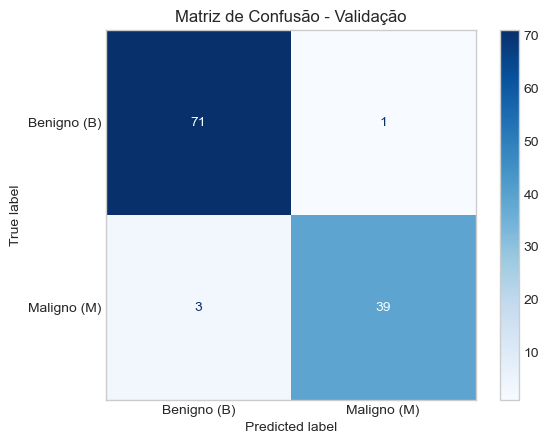

In [12]:
# Treino e Avaliacao Detalhada com o Melhor Modelo (Ex: Logistic Regression / SVC)
best_cls_pipe = Pipeline(steps=[('scaler', StandardScaler()), ('algo', LogisticRegression())])
best_cls_pipe.fit(X_train_c, y_train_c)
y_pred_val = best_cls_pipe.predict(X_val_c)

print("--- Relatório de Classificação (Validação Interna) ---")
print(classification_report(y_val_c, y_pred_val))

# Matriz de Confusao
cm = confusion_matrix(y_val_c, y_pred_val, labels=['B', 'M'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benigno (B)', 'Maligno (M)'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusão - Validação")
plt.grid(False)
plt.show()

# Treino no dataset completo e predicao para o teste
best_cls_pipe.fit(X_cls, y_cls)
preds_cls = best_cls_pipe.predict(test_cls)

---
## Parte 3: Gerando os Arquivos de Submissão

In [13]:
# 3.1 Submissao - Regressao
sub_reg = pd.DataFrame({
    'id': test_reg.index,
    'score': np.round(preds_reg, 2)
})
sub_reg.to_csv('submission_regressao.csv', index=False)
print("--- Amostra Submission Regressão ---")
print(sub_reg.head())

--- Amostra Submission Regressão ---
   id  score
0   0  13.34
1   1  11.42
2   2   4.77
3   3  11.55
4   4  11.98


In [17]:
# 3.2 Submissao - Classificacao
# Converte 'M' e 'B' para 1 e 0 
preds_cls_numeric = [1 if p == 'M' or p == 1 else 0 for p in preds_cls]

sub_cls = pd.DataFrame({
    'id': range(len(preds_cls_numeric)),
    'diagnosis': preds_cls_numeric
})

sub_cls.to_csv('submission_classificacao.csv', index=False)
print(f"Submissão de classificação gerada com {len(sub_cls)} linhas!")
print(sub_cls.head())

Submissão de classificação gerada com 40 linhas!
   id  diagnosis
0   0          0
1   1          0
2   2          0
3   3          1
4   4          0
